# JAGUAR Legacy POX 52 Joint Fit

This notebook resolves POX 52 by name, downloads native Legacy Survey DR10 brick coadds and inverse-variance maps, constructs empirical PSFs from bright compact sources in the brick images, cuts local fitting stamps, and runs a joint AGN + host + scene fit with grahspj SED coupling.


In [1]:
from dataclasses import replace
from pathlib import Path
import sys
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
for src in (repo_root / "src", repo_root.parent / "grahspj" / "src"):
    if src.is_dir() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from jaguar import (
    SceneComponentConfig,
    SedComponentConfig,
    SourceDetectionConfig,
    build_components_from_detections,
    build_empirical_psfs_for_bands,
    construct_empirical_psf,
    EmpiricalPsfConfig,
    find_empirical_psf_candidates,
    build_detection_image,
    detect_sources,
    ImageFitConfig,
    initialize_sed_component_amplitudes_from_pixels,
    JointFitConfig,
    build_grahspj_config_from_image_bands,
    download_galight_hsc_example,
    download_legacy_survey_bricks_table,
    download_legacy_survey_coadd_band,
    fit,
    find_legacy_survey_brick,
    load_hsc_band,
    load_legacy_survey_coadd_band,
    read_legacy_survey_coadd_image,
)
from jaguar.plotting import plot_config, plot_empirical_psf_selection, plot_fit, plot_psf_candidates, plot_sed
from jaguar.mplstyle import style_path
plt.style.use(style_path())



/Users/colinburke/miniforge3/envs/sed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Target Coordinates


In [2]:
target_coord = SkyCoord.from_name("Pox 52")
target_ra_dec = (float(target_coord.ra.deg), float(target_coord.dec.deg))
target_redshift = 0.02179
target_ra_dec, target_redshift


((180.737219, -20.934155), 0.02179)

## Download Legacy DR10 Brick Coadds and Build Empirical PSFs


In [47]:
# Download native DR10 brick coadds once, then build empirical PSFs from local search cutouts.
legacy_region = "south"
legacy_data_dir = repo_root / "data/legacy_dr10"
fit_radius = 45
band_specs = {
    "g": "ctio.decam.g",
    "r": "ctio.decam.r",
    "i": "ctio.decam.i",
}
psf_config = EmpiricalPsfConfig(
    psf_size=23,
    psf_search_radius=600,
    prefer_common_stars=True,
    require_gaia_match=False,
    annotate_gaia_matches=False,
    gaia_xmatch_timeout=5.0,
    psf_padding_pixels=2,
    max_edge_flux_fraction=0.08,
    max_fwhm_fractional_scatter=0.2
)

psf_result = build_empirical_psfs_for_bands(
    band_specs=band_specs,
    target_ra_dec=target_ra_dec,
    data_dir=legacy_data_dir,
    region=legacy_region,
    fit_radius=fit_radius,
    config=psf_config,
)
image_bands = psf_result.image_bands

[(psf_result.brick, band.filter_name, band.image.shape, band.psf.shape, band.pixel_scale, band.counts_per_mjy) for band in image_bands]


g: 511 detected segments
   241 rejected by edge_flux
   123 rejected by fwhm_scatter
   6 rejected by saturated_core
   1 rejected by target_exclusion
   31 rejected by stamp_outside
   8 rejected by neighbor
   69 rejected by candidate_pool_limit
   32 accepted
r: 225 detected segments
   84 rejected by edge_flux
   61 rejected by fwhm_scatter
   3 rejected by saturated_core
   1 rejected by target_exclusion
   16 rejected by stamp_outside
   1 rejected by size
   1 rejected by neighbor
   26 rejected by candidate_pool_limit
   32 accepted
i: 288 detected segments
   125 rejected by edge_flux
   52 rejected by fwhm_scatter
   9 rejected by saturated_core
   1 rejected by target_exclusion
   18 rejected by stamp_outside
   2 rejected by size
   4 rejected by neighbor
   45 rejected by candidate_pool_limit
   32 accepted


[('1806m210',
  'ctio.decam.g',
  (91, 91),
  (23, 23),
  0.26200000000000007,
  275.4228703338169),
 ('1806m210',
  'ctio.decam.r',
  (91, 91),
  (23, 23),
  0.26200000000000007,
  275.4228703338169),
 ('1806m210',
  'ctio.decam.i',
  (91, 91),
  (23, 23),
  0.26200000000000007,
  275.4228703338169)]

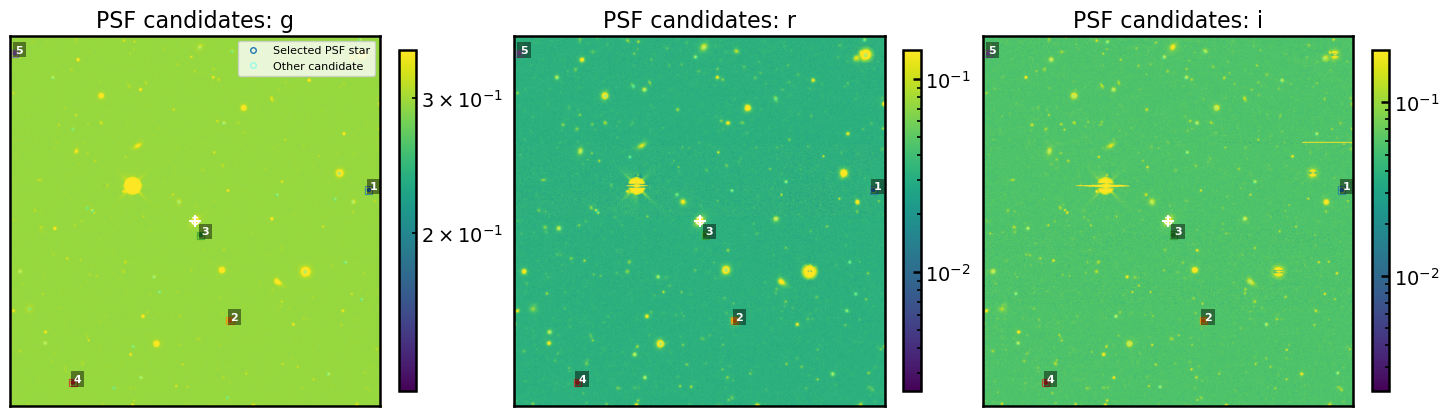

[('g', 32, 5), ('r', 32, 5), ('i', 32, 5)]

In [48]:
fig, axes = plot_empirical_psf_selection(psf_result, show_all_candidates=True)
plt.show()

[(band_code, len(result.candidates), len(result.selected_candidates)) for band_code, result in psf_result.bands.items()]


## Detect Extra Scene Sources


In [49]:
detection_cfg = SourceDetectionConfig(
    threshold=8.0,
    npixels=5,
    target_exclusion_radius_pix=12.0,
    deblend=True,
    deblend_nlevels=32,
    deblend_contrast=1e-2,
    max_sources=20,
    extendedness_threshold=1.0,
)
detection_image = build_detection_image(image_bands, detection_cfg)
detections = detect_sources(image_bands, detection_cfg)
[(d.id, d.classification, round(d.x_offset_pix, 2), round(d.y_offset_pix, 2), round(d.extendedness, 2), round(d.snr, 1)) for d in detections]


[(1, 'galaxy', 17.72, -43.85, 0.72, 311.3)]

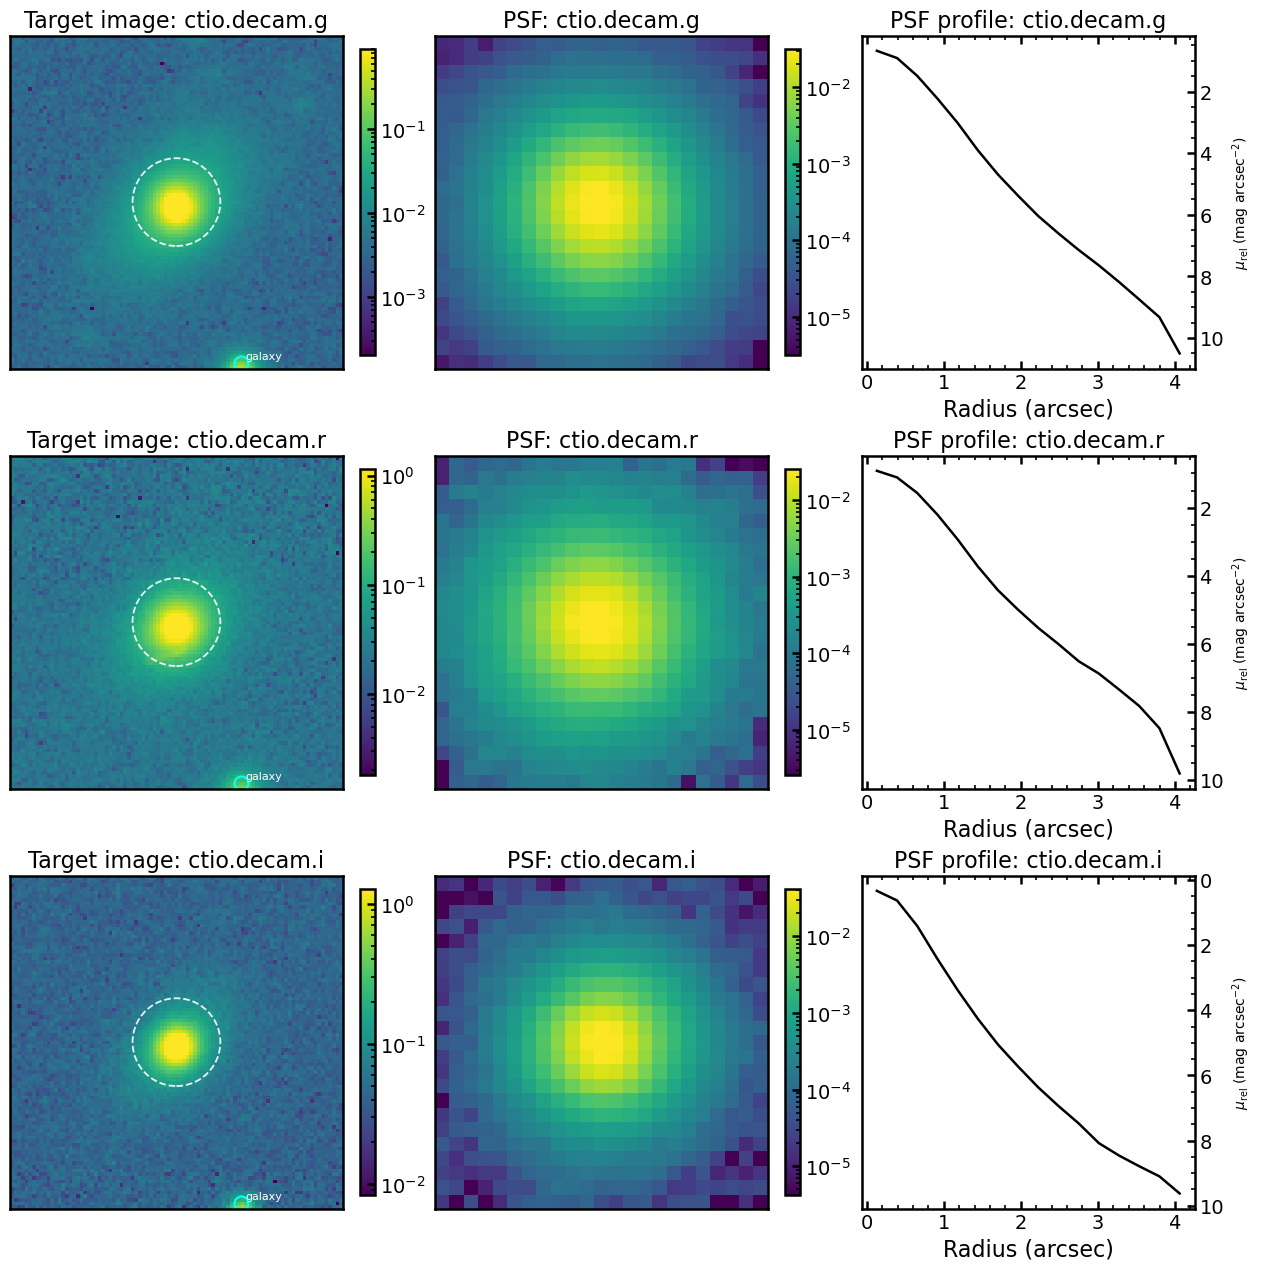

In [50]:
fig, axes = plot_config(image_bands, detections, detection_cfg, detection_image=detection_image)
plt.show()





## Fit Multi-band AGN + Host


In [55]:
grahspj_cfg = build_grahspj_config_from_image_bands(
    image_bands,
    object_id="pox_52",
    redshift=target_redshift,
    dsps_ssp_fn=str(repo_root.parent / "jaxqsofit/tempdata.h5"),
)
base_sed_components = [
    SedComponentConfig(name="agn", kind="agn", spatial="point", grahspj_config=grahspj_cfg),
    SedComponentConfig(name="host_inner", kind="host", spatial="extended", grahspj_config=grahspj_cfg),
    SedComponentConfig(name="host_outer", kind="host", spatial="extended", grahspj_config=grahspj_cfg),
]
base_scene_components = [
    SceneComponentConfig(name="agn", sed_component="agn", kind="point", fit_position=True, fixed_center_x_pix=0.0, fixed_center_y_pix=0.0),
    SceneComponentConfig(
        name="host_inner",
        sed_component="host_inner",
        kind="sersic",
        fit_position=False,
        fixed_center_x_pix=0.0,
        fixed_center_y_pix=0.0,
        fixed_reff_arcsec=0.45,
        fixed_n_sersic=2.0,
        reff_arcsec_loc=0.45,
        reff_arcsec_sigma=0.15,
        min_reff_arcsec=0.25,
        n_sersic_loc=2.0,
        n_sersic_sigma=0.5,
    ),
    SceneComponentConfig(
        name="host_outer",
        sed_component="host_outer",
        kind="sersic",
        fit_position=False,
        fixed_center_x_pix=0.0,
        fixed_center_y_pix=0.0,
        fixed_reff_arcsec=1.8,
        fixed_n_sersic=1.0,
        reff_arcsec_loc=1.8,
        reff_arcsec_sigma=0.6,
        min_reff_arcsec=0.8,
        n_sersic_loc=1.0,
        n_sersic_sigma=0.3,
    ),
]
extra_sed_components, extra_scene_components = build_components_from_detections(detections, grahspj_cfg, detection_cfg)
scene_components = [*base_scene_components, *extra_scene_components]
sed_components = initialize_sed_component_amplitudes_from_pixels(
    image_bands,
    [*base_sed_components, *extra_sed_components],
    scene_components,
    total_grahspj_config=grahspj_cfg,
    host_to_agn_initial_flux_ratio=0.05,
)
cfg = JointFitConfig(
    image_bands=image_bands,
    image=ImageFitConfig(fit_background=True, background_default=0.0),
    sed_components=sed_components,
    scene_components=scene_components,
    grahspj_config=grahspj_cfg,
    joint_grahspj_fitting=False,
)
result = fit(cfg, fit_method="map_only", map_steps=2000, learning_rate=5.0e-3, progress_bar=True)
result.summary()



100%|██████████| 2000/2000 [00:17<00:00, 116.43it/s, init loss: 65887.5686, avg. loss [1901-2000]: 37497.9840]


{'agn/center_x_pix': 0.5437534008558815,
 'agn/center_y_pix': -1.3947700779479395,
 'host_inner/reff_arcsec': 1.2890796900236772,
 'host_inner/n_sersic': 1.136116128877445,
 'host_inner/e1': 0.08238283289099595,
 'host_inner/e2': 0.18182921769913843,
 'host_outer/reff_arcsec': 3.7718898924485353,
 'host_outer/n_sersic': 0.7175965728547009,
 'host_outer/e1': -0.04768707268615356,
 'host_outer/e2': 0.21360700143340883,
 'det_1_image/center_x_pix': 17.641967979603063,
 'det_1_image/center_y_pix': -44.91241731823064,
 'det_1_image/reff_arcsec': 0.3566291358939141,
 'det_1_image/n_sersic': 2.104211646926812,
 'det_1_image/e1': 0.8195967032718228,
 'det_1_image/e2': -0.07064641803021081,
 'agn/ctio.decam.g/log_flux': 4.859535733025013,
 'host_inner/ctio.decam.g/log_flux': 2.8709841840885053,
 'host_outer/ctio.decam.g/log_flux': 3.175228058647249,
 'det_1_image/ctio.decam.g/log_flux': 1.0593705401154516,
 'agn/ctio.decam.r/log_flux': 5.2959655829376135,
 'host_inner/ctio.decam.r/log_flux': 3.

## Inspect Image Components and Residuals


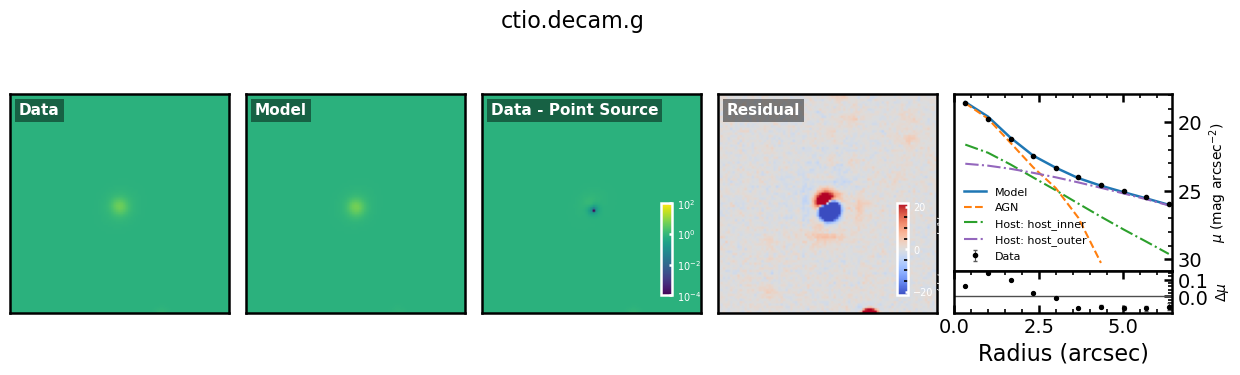

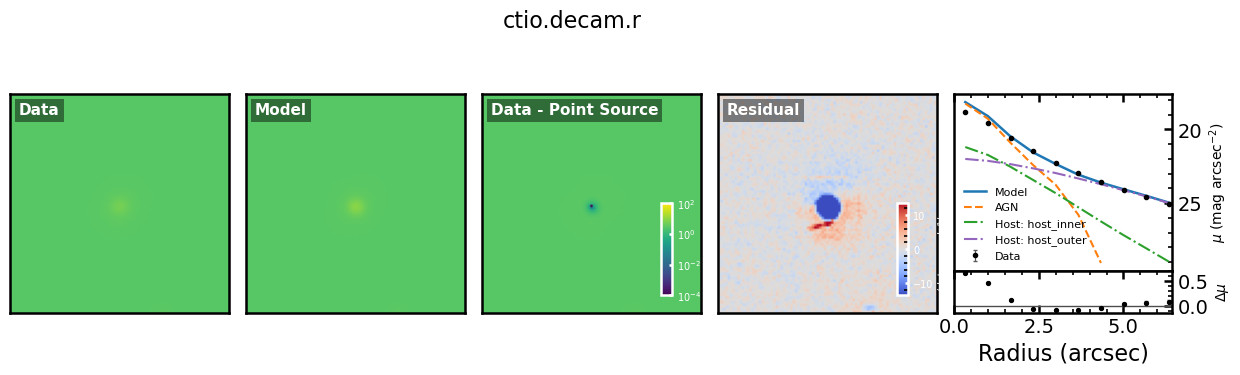

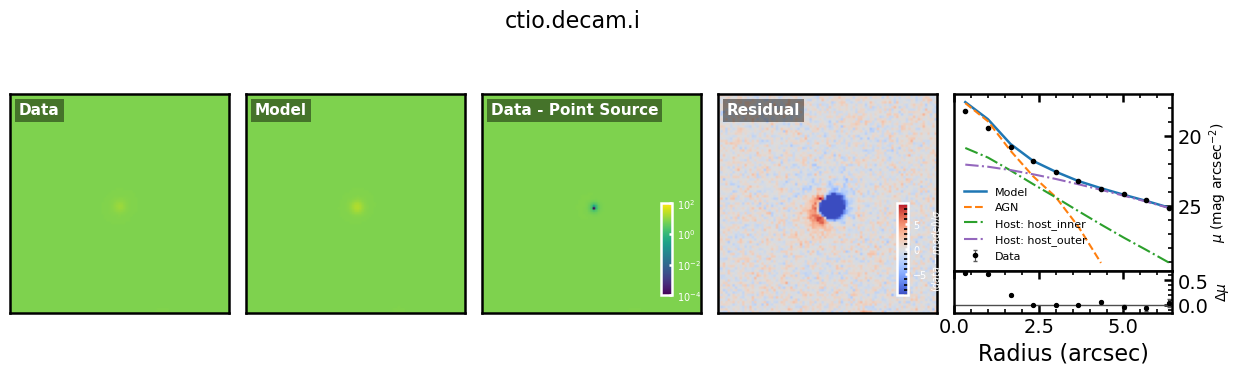

In [57]:
for band in image_bands:
    fig, axes = plot_fit(result, band.filter_name, shared_vmin=1e-4, shared_vmax=1e2)
    fig.suptitle(band.filter_name)
plt.show()


In [53]:
## Plot the Image-band SED


In [54]:
fig = plot_sed(result, show=True)

ValueError: zero-size array to reduction operation fmin which has no identity